# Uncertainty-Aware Emotion Analysis for Journaling

**Pipeline:** `roberta-base` → Weighted CrossEntropy Loss → LR Warmup → Temperature Scaling → MSP + Entropy → NRCLex Soft Fusion

| Component | Method | Purpose |
|---|---|---|
| Base Model | `roberta-base` (fine-tuned) | Contextual emotion classification |
| Training Loss | Weighted CrossEntropy | Handles class imbalance |
| Data Augmentation | SynonymAug (all minority classes) | Balances class distribution |
| LR Scheduler | Linear Warmup | Prevents early instability |
| Calibration | Temperature Scaling | Fixes overconfidence |
| Uncertainty | MSP + Predictive Entropy | Reliability signals |
| Refinement | NRCLex Soft Fusion | Handles emotionally explicit vocabulary |
| Evaluation | Accuracy, Weighted F1, ECE | Standard + calibration metrics |

## 1 — Install Dependencies

In [1]:
!pip install transformers==4.38.2 \
            accelerate==0.27.2 \
            datasets==2.18.0 \
            tokenizers==0.15.2 \
            scikit-learn \
            nlpaug \
            nrclex \
            matplotlib \
            seaborn -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.7/130.7 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.0/280.0 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.5/510.5 kB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 19.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.3.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.38.2 which is 

## 2 — Imports

In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.utils.data import DataLoader
from torch.optim import AdamW
from tqdm import tqdm
import nlpaug.augmenter.word as naw
from nrclex import NRCLex

print(f'PyTorch : {torch.__version__}')
print(f'Device  : {"cuda" if torch.cuda.is_available() else "cpu"}')

PyTorch : 2.10.0+cu128
Device  : cuda


## 3 — Load & Merge Datasets

In [3]:
# Local dataset
df = pd.read_csv('emotions.csv')

# HuggingFace: dair-ai/emotion
hf_ds     = load_dataset('dair-ai/emotion')
label_map = {0:'sadness', 1:'joy', 2:'love', 3:'anger', 4:'fear', 5:'surprise'}
hf_df     = pd.DataFrame({
    'sentences': hf_ds['train']['text'],
    'emotions' : [label_map[i] for i in hf_ds['train']['label']]
})

df = pd.concat([df, hf_df], ignore_index=True)
df = df.dropna()
df = df[df['sentences'].astype(str).str.strip() != '']
df = df.reset_index(drop=True)

print('Class distribution (pre-augmentation):')
print(df['emotions'].value_counts())
print(f'\nTotal samples: {len(df)}')

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Class distribution (pre-augmentation):
emotions
joy         5693
sadness     4957
anger       2298
fear        2051
love        1384
surprise     601
Name: count, dtype: int64

Total samples: 16984


## 4 — Data Augmentation (All Minority Classes)


In [29]:
import nltk
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

aug = naw.ContextualWordEmbsAug(
    model_path='roberta-base',
    action='substitute',
    aug_p=0.15
)

# Target: bring every class up to the majority class count
class_counts = df['emotions'].value_counts()
target_count = int(class_counts.max())
print(f'Target count per class : {target_count}')
print(f'\nClass counts before augmentation:\n{class_counts}\n')

augmented = []

for emotion, count in class_counts.items():
    needed = target_count - count
    if needed <= 0:
        print(f'[{emotion}] already at target ({count}) — skipping')
        continue

    print(f'Augmenting [{emotion}]: {count} → {target_count} (+{needed} samples)')
    class_df = df[df['emotions'] == emotion]

    generated = 0
    while generated < needed:
        for _, row in class_df.iterrows():
            if generated >= needed:
                break
            try:
                aug_text = aug.augment(str(row['sentences']))[0]
                augmented.append({'sentences': aug_text, 'emotions': emotion})
                generated += 1
            except Exception:
                pass

df = pd.concat([df, pd.DataFrame(augmented)], ignore_index=True)
df = df.dropna().reset_index(drop=True)

print('\nClass distribution (post-augmentation):')
print(df['emotions'].value_counts())
print(f'\nTotal samples: {len(df)}')

Target count per class : 5693

Class counts before augmentation:
emotions
sadness     5693
joy         5693
fear        5693
anger       5693
love        5693
surprise    5693
Name: count, dtype: int64

[sadness] already at target (5693) — skipping
[joy] already at target (5693) — skipping
[fear] already at target (5693) — skipping
[anger] already at target (5693) — skipping
[love] already at target (5693) — skipping
[surprise] already at target (5693) — skipping

Class distribution (post-augmentation):
emotions
sadness     5693
joy         5693
fear        5693
anger       5693
love        5693
surprise    5693
Name: count, dtype: int64

Total samples: 34158


## 5 — Label Encoding & Train / Val Split

In [31]:
le          = LabelEncoder()
df['label'] = le.fit_transform(df['emotions'])
num_labels  = len(le.classes_)

print(f'Labels ({num_labels}): {list(le.classes_)}')

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['sentences'], df['label'],
    test_size=0.1, stratify=df['label'], random_state=42
)
val_texts_list = list(val_texts)

print(f'Train: {len(train_texts):,} | Val: {len(val_texts):,}')

Labels (6): ['anger', 'fear', 'joy', 'love', 'sadness', 'surprise']
Train: 30,742 | Val: 3,416


## 6 — Tokenizer & Model

In [32]:
MODEL_NAME = 'roberta-base'
MAX_LEN    = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(texts):
    return tokenizer(list(texts), padding=True, truncation=True, max_length=MAX_LEN)

train_encodings = tokenize(train_texts)
val_encodings   = tokenize(val_texts)

model  = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_labels)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

print(f'Model  : {MODEL_NAME}')
print(f'Device : {device}')
print(f'Params : {sum(p.numel() for p in model.parameters()):,}')

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model  : roberta-base
Device : cuda
Params : 124,650,246


## 7 — Dataset & DataLoaders

In [33]:
class EmotionDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels    = list(labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

BATCH_SIZE   = 16
train_loader = DataLoader(EmotionDataset(train_encodings, train_labels), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(EmotionDataset(val_encodings,   val_labels),   batch_size=BATCH_SIZE)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Train batches: 1922 | Val batches: 214


## 8 — Weighted CrossEntropy Loss + AdamW + LR Warmup Scheduler


In [34]:
# ── Compute class weights inversely proportional to frequency ──
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(num_labels),
    y=df['label'].values
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

print('Class weights (higher = model penalized more for errors on this class):')
for cls, w in zip(le.classes_, class_weights):
    print(f'  {cls:<10} → {w:.4f}')

# ── Weighted CrossEntropy Loss ──
loss_fn   = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)

# ── LR warmup scheduler ──
EPOCHS       = 5
total_steps  = len(train_loader) * EPOCHS
warmup_steps = total_steps // 10   # 10% warmup

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f'\nLoss       : Weighted CrossEntropyLoss')
print(f'Optimizer  : AdamW(lr=2e-5, weight_decay=0.01)')
print(f'Epochs     : {EPOCHS}')
print(f'Total steps: {total_steps} | Warmup steps: {warmup_steps}')

Class weights (higher = model penalized more for errors on this class):
  anger      → 1.0000
  fear       → 1.0000
  joy        → 1.0000
  love       → 1.0000
  sadness    → 1.0000
  surprise   → 1.0000

Loss       : Weighted CrossEntropyLoss
Optimizer  : AdamW(lr=2e-5, weight_decay=0.01)
Epochs     : 5
Total steps: 9610 | Warmup steps: 961


## 9 — Helper: ECE + Validation

In [35]:
def compute_ece(confidences, predictions, labels, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    ece  = 0.0
    for i in range(n_bins):
        mask = (confidences >= bins[i]) & (confidences < bins[i+1])
        if mask.sum() > 0:
            bin_acc  = (predictions[mask] == labels[mask]).mean()
            bin_conf = confidences[mask].mean()
            ece     += mask.mean() * abs(bin_acc - bin_conf)
    return float(ece)


def run_validation(model, val_loader, device, temp_model=None):
    model.eval()
    preds, true, confidences, entropies, all_probs = [], [], [], [], []  # fix: added all_probs

    with torch.no_grad():
        for batch in val_loader:
            batch  = {k: v.to(device) for k, v in batch.items()}
            logits = model(**batch).logits
            if temp_model is not None:
                logits = temp_model(logits)
            probs      = torch.softmax(logits, dim=1)
            pred       = torch.argmax(probs, dim=1)
            confidence = torch.max(probs, dim=1).values
            entropy    = -torch.sum(probs * torch.log(probs + 1e-8), dim=1)

            preds.extend(pred.cpu().numpy())
            true.extend(batch['labels'].cpu().numpy())
            confidences.extend(confidence.cpu().numpy())
            entropies.extend(entropy.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())          # fix: collect full softmax vectors

    preds       = np.array(preds)
    true        = np.array(true)
    confidences = np.array(confidences)
    entropies   = np.array(entropies)
    all_probs   = np.array(all_probs)                      # fix: shape (val_size, num_labels)

    return {
        'acc'        : accuracy_score(true, preds),
        'f1'         : f1_score(true, preds, average='weighted'),
        'ece'        : compute_ece(confidences, preds, true),
        'avg_conf'   : confidences.mean(),
        'avg_entropy': entropies.mean(),
        'preds'      : preds,
        'true'       : true,
        'confidences': confidences,
        'entropies'  : entropies,
        'probs'      : all_probs,                          # fix: added to returned dict
    }

print('ECE + validation helpers defined')

ECE + validation helpers defined


## 10 — Training Loop (Weighted CrossEntropy + Warmup + Checkpointing)

In [36]:
SAVE_DIR = './emotion_model_final'
import os
os.makedirs(SAVE_DIR, exist_ok=True)

history = []
best_f1 = 0.0

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0

    for batch in tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS}'):
        batch  = {k: v.to(device) for k, v in batch.items()}
        logits = model(**batch).logits

        loss = loss_fn(logits, batch['labels'])

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    v        = run_validation(model, val_loader, device)

    history.append({
        'epoch': epoch+1, 'loss': avg_loss,
        'acc': v['acc'], 'f1': v['f1'], 'ece': v['ece'],
        'avg_conf': v['avg_conf'], 'avg_entropy': v['avg_entropy'],
        'lr': scheduler.get_last_lr()[0]
    })

    print(f'\nEpoch {epoch+1}/{EPOCHS}')
    print(f'  Loss     : {avg_loss:.4f}')
    print(f'  Accuracy : {v["acc"]:.4f}')
    print(f'  F1       : {v["f1"]:.4f}')
    print(f'  ECE      : {v["ece"]:.4f}')
    print(f'  LR       : {scheduler.get_last_lr()[0]:.2e}')

    if v['f1'] > best_f1:
        best_f1 = v['f1']
        torch.save(model.state_dict(), f'{SAVE_DIR}/best_checkpoint.pt')
        print(f'  ✅ Best model saved (F1={best_f1:.4f})')

print(f'\nTraining complete. Best Val F1: {best_f1:.4f}')

Epoch 1/5: 100%|██████████| 1922/1922 [09:11<00:00,  3.48it/s]



Epoch 1/5
  Loss     : 0.6866
  Accuracy : 0.9122
  F1       : 0.9122
  ECE      : 0.0185
  LR       : 1.78e-05
  ✅ Best model saved (F1=0.9122)


Epoch 2/5: 100%|██████████| 1922/1922 [09:09<00:00,  3.50it/s]



Epoch 2/5
  Loss     : 0.2516
  Accuracy : 0.9335
  F1       : 0.9333
  ECE      : 0.0243
  LR       : 1.33e-05
  ✅ Best model saved (F1=0.9333)


Epoch 3/5: 100%|██████████| 1922/1922 [09:08<00:00,  3.50it/s]



Epoch 3/5
  Loss     : 0.1710
  Accuracy : 0.9359
  F1       : 0.9361
  ECE      : 0.0378
  LR       : 8.89e-06
  ✅ Best model saved (F1=0.9361)


Epoch 4/5: 100%|██████████| 1922/1922 [09:08<00:00,  3.50it/s]



Epoch 4/5
  Loss     : 0.1191
  Accuracy : 0.9508
  F1       : 0.9507
  ECE      : 0.0316
  LR       : 4.44e-06
  ✅ Best model saved (F1=0.9507)


Epoch 5/5: 100%|██████████| 1922/1922 [09:08<00:00,  3.50it/s]



Epoch 5/5
  Loss     : 0.0793
  Accuracy : 0.9561
  F1       : 0.9560
  ECE      : 0.0342
  LR       : 0.00e+00
  ✅ Best model saved (F1=0.9560)

Training complete. Best Val F1: 0.9560


## 11 — Training History Plot

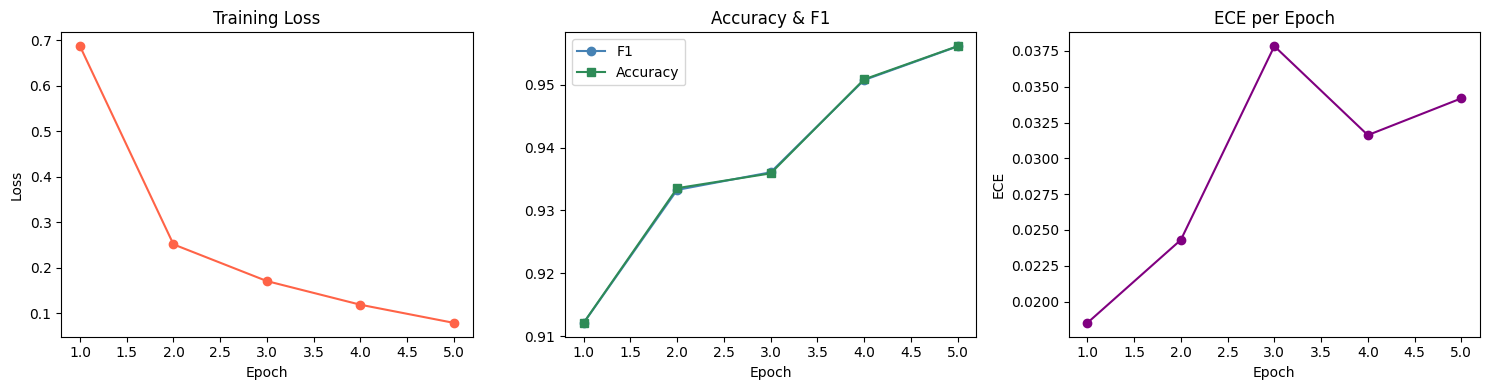

In [37]:
hist_df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(hist_df['epoch'], hist_df['loss'], marker='o', color='tomato')
axes[0].set_title('Training Loss'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')

axes[1].plot(hist_df['epoch'], hist_df['f1'],  marker='o', color='steelblue', label='F1')
axes[1].plot(hist_df['epoch'], hist_df['acc'], marker='s', color='seagreen',  label='Accuracy')
axes[1].set_title('Accuracy & F1'); axes[1].set_xlabel('Epoch'); axes[1].legend()

axes[2].plot(hist_df['epoch'], hist_df['ece'], marker='o', color='purple')
axes[2].set_title('ECE per Epoch'); axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('ECE')

plt.tight_layout(); plt.show()

## 12 — Load Best Checkpoint
> Load the best F1 checkpoint saved during training before calibration and evaluation.

In [38]:
model.load_state_dict(torch.load(f'{SAVE_DIR}/best_checkpoint.pt', map_location=device))
model.eval()
print('Best checkpoint loaded.')

Best checkpoint loaded.


## 13 — Temperature Scaling (Post-Hoc Calibration)
> Guo et al., "On Calibration of Modern Neural Networks", ICML 2017
> Divides logits by a scalar T optimized via L-BFGS on the validation set.
> T > 1 softens overconfident predictions. Does NOT change accuracy.

In [39]:
class TemperatureScaling(nn.Module):
    def __init__(self, init_temp=1.5):
        super().__init__()
        self.temperature = nn.Parameter(torch.ones(1) * init_temp)

    def forward(self, logits):
        return logits / self.temperature.clamp(min=1e-6)


def calibrate_temperature(model, val_loader, device):
    temp_model  = TemperatureScaling().to(device)
    optimizer_t = torch.optim.LBFGS([temp_model.temperature], lr=0.01, max_iter=100)

    all_logits, all_labels = [], []
    model.eval()
    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            all_logits.append(model(**batch).logits)
            all_labels.append(batch['labels'])

    all_logits = torch.cat(all_logits)
    all_labels = torch.cat(all_labels)

    def eval_step():
        optimizer_t.zero_grad()
        loss = F.cross_entropy(temp_model(all_logits), all_labels)
        loss.backward()
        return loss

    optimizer_t.step(eval_step)
    T = temp_model.temperature.item()
    print(f'Optimal T = {T:.4f}  {"(overconfident → softened)" if T > 1 else "(underconfident → sharpened)"}')
    return temp_model


temp_model = calibrate_temperature(model, val_loader, device)

Optimal T = 1.6234  (overconfident → softened)


## 14 — ECE Before vs After Temperature Scaling

In [40]:
v_raw = run_validation(model, val_loader, device, temp_model=None)
v_cal = run_validation(model, val_loader, device, temp_model=temp_model)

print(f'ECE Before Temperature Scaling : {v_raw["ece"]:.4f}')
print(f'ECE After  Temperature Scaling : {v_cal["ece"]:.4f}')
print(f'Improvement                    : {v_raw["ece"] - v_cal["ece"]:.4f}')

ECE Before Temperature Scaling : 0.0342
ECE After  Temperature Scaling : 0.0145
Improvement                    : 0.0197


## 15 — Threshold Tuning on Validation Set
> Empirically select the confidence threshold for NRCLex soft fusion activation.

In [41]:
NRC_MAP = {
    'joy': 'joy', 'sadness': 'sadness', 'anger': 'anger',
    'fear': 'fear', 'surprise': 'surprise', 'love': 'love',
    'trust': 'joy', 'anticipation': 'surprise', 'disgust': 'anger'
}


def get_nrclex_vec(text):
    """Return normalized NRCLex probability vector over our 6 classes."""
    try:
        nrc    = NRCLex(text)
        scores = nrc.raw_emotion_scores
    except Exception:
        return None

    vec = np.zeros(num_labels)
    for emotion, score in scores.items():
        mapped = NRC_MAP.get(emotion)
        if mapped and mapped in le.classes_:
            idx      = le.transform([mapped])[0]
            vec[idx] += score

    if vec.sum() > 0:
        return vec / vec.sum()
    return None


LEXICON_WEIGHT = 0.3
thresholds     = np.arange(0.50, 0.90, 0.05)
best_t, best_f1_t = 0.65, 0.0

for t in thresholds:
    refined_preds = v_cal['preds'].copy()
    for i, (conf, pred) in enumerate(zip(v_cal['confidences'], v_cal['preds'])):
        if conf < t:
            lex_vec = get_nrclex_vec(val_texts_list[i])
            if lex_vec is not None:
                model_prob       = v_cal['probs'][i]          # fix: full softmax vector
                blended          = (1 - LEXICON_WEIGHT) * model_prob + LEXICON_WEIGHT * lex_vec
                refined_preds[i] = np.argmax(blended)

    f1_t = f1_score(v_cal['true'], refined_preds, average='weighted')
    if f1_t > best_f1_t:
        best_f1_t, best_t = f1_t, t

CONFIDENCE_THRESHOLD = best_t
print(f'Optimal confidence threshold : {CONFIDENCE_THRESHOLD:.2f}')
print(f'Val F1 at optimal threshold  : {best_f1_t:.4f}')

Optimal confidence threshold : 0.50
Val F1 at optimal threshold  : 0.9560


In [42]:
print(v_cal.keys())          # should include 'probs'
print(v_cal['probs'].shape)  # should be (val_size, num_labels)

dict_keys(['acc', 'f1', 'ece', 'avg_conf', 'avg_entropy', 'preds', 'true', 'confidences', 'entropies', 'probs'])
(3416, 6)


## 16 — Hybrid Prediction Function (Full Pipeline)

**Decision logic:**
```
calibrated_probs = softmax(logits / T)

IF confidence >= THRESHOLD:
    final = model_prediction          # high confidence — trust model fully
ELSE:
    lex_vec = NRCLex(text) probabilities
    IF lex_vec available:
        final = softblend(model_probs, lex_vec, alpha=0.3)
    ELSE:
        final = model_prediction      # no NRCLex signal — fall back
```

In [ ]:
def predict_emotion(text, threshold=CONFIDENCE_THRESHOLD):
    """
    Full inference pipeline with Temperature Scaling + NRCLex soft fusion.

    Returns dict with:
        emotion, confidence, entropy, uncertainty,
        top3, refined_by_nrclex, model_raw_emotion
    """
    model.eval()
    inputs = tokenizer(
        text, return_tensors='pt',
        truncation=True, padding=True, max_length=MAX_LEN
    ).to(device)

    with torch.no_grad():                                       
        raw_logits = model(**inputs).logits
        cal_logits = temp_model(raw_logits)
        probs      = torch.softmax(cal_logits, dim=-1)[0].cpu()

    # Uncertainty signals
    pred_id       = torch.argmax(probs).item()
    confidence    = probs[pred_id].item()
    raw_entropy   = (-probs * torch.log(probs + 1e-8)).sum().item()
    norm_entropy  = raw_entropy / np.log(num_labels)
    model_emotion = le.inverse_transform([pred_id])[0]

    # Top-3
    top3_idx = torch.topk(probs, min(3, num_labels))
    top3 = [
        {'emotion': le.inverse_transform([i.item()])[0], 'confidence': round(s.item(), 4)}
        for i, s in zip(top3_idx.indices, top3_idx.values)
    ]

    # NRCLex soft fusion — only when model is uncertain
    final_emotion = model_emotion
    refined       = False
    probs_np      = probs.numpy()                                

    if confidence < threshold:
        lex_vec = get_nrclex_vec(text)
        if lex_vec is not None:
            blended       = (1 - LEXICON_WEIGHT) * probs_np + LEXICON_WEIGHT * lex_vec
            final_pred_id = np.argmax(blended)
            final_emotion = le.inverse_transform([final_pred_id])[0]
            refined       = True

    # Uncertainty tier
    if confidence >= 0.80:   uncertainty_level = 'Low'
    elif confidence >= 0.60: uncertainty_level = 'Moderate'
    else:                    uncertainty_level = 'High'

    return {
        'emotion'           : final_emotion,
        'confidence'        : round(confidence, 4),
        'entropy'           : round(norm_entropy, 4),
        'uncertainty'       : uncertainty_level,
        'top3'              : top3,
        'refined_by_nrclex' : refined,
        'model_raw_emotion' : model_emotion,
    }


print('predict_emotion() — deployment-ready hybrid function loaded')

predict_emotion() — deployment-ready hybrid function loaded


In [44]:
print("FINAL LABEL DISTRIBUTION")
print(df['label'].value_counts(normalize=True))

FINAL LABEL DISTRIBUTION
label
4    0.166667
2    0.166667
1    0.166667
0    0.166667
3    0.166667
5    0.166667
Name: proportion, dtype: float64


## 17 — Test on Journal Entries

In [45]:
test_entries = [
    "I feel so happy and excited about today!",
    "I am really angry and frustrated with everything.",
    "I feel a bit down and lonely today.",
    "I am nervous and scared about what comes next.",
    "I love spending time with my family.",
    "That was completely unexpected, I'm shocked!",
    "Today was okay, nothing special happened.",
    "I guess it's fine, not great but not terrible either.",
    "I don't know how to feel about this."
]

print(f'{"Text":<50} {"Emotion":<10} {"Conf":>6} {"Entropy":>8} {"Uncertainty":<12} {"NRCLex":>6}')
print('-' * 100)
for text in test_entries:
    r = predict_emotion(text)
    print(f'{text[:48]:<50} {r["emotion"]:<10} {r["confidence"]:>6.4f} {r["entropy"]:>8.4f} {r["uncertainty"]:<12} {str(r["refined_by_nrclex"]):>6}')

Text                                               Emotion      Conf  Entropy Uncertainty  NRCLex
----------------------------------------------------------------------------------------------------
I feel so happy and excited about today!           joy        0.9910   0.0366 Low           False
I am really angry and frustrated with everything   anger      0.9760   0.0828 Low           False
I feel a bit down and lonely today.                sadness    0.9883   0.0458 Low           False
I am nervous and scared about what comes next.     fear       0.9874   0.0490 Low           False
I love spending time with my family.               joy        0.9872   0.0484 Low           False
That was completely unexpected, I'm shocked!       surprise   0.9806   0.0702 Low           False
Today was okay, nothing special happened.          joy        0.9888   0.0437 Low           False
I guess it's fine, not great but not terrible ei   joy        0.9848   0.0569 Low           False
I don't know how 

In [46]:
print(CONFIDENCE_THRESHOLD)

0.5


## 18 — Ablation Study
> Demonstrates contribution of each pipeline component.

In [ ]:
def evaluate_variant(use_temp=False, use_nrclex=False):
    model.eval()
    preds, true, confidences, all_probs = [], [], [], []       

    with torch.no_grad():
        for batch in val_loader:
            batch  = {k: v.to(device) for k, v in batch.items()}
            logits = model(**batch).logits
            if use_temp:
                logits = temp_model(logits)
            probs      = torch.softmax(logits, dim=1)
            confidence = torch.max(probs, dim=1).values
            pred       = torch.argmax(probs, dim=1)
            preds.extend(pred.cpu().numpy())
            true.extend(batch['labels'].cpu().numpy())
            confidences.extend(confidence.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())             

    preds       = np.array(preds)
    true        = np.array(true)
    confidences = np.array(confidences)
    all_probs   = np.array(all_probs)                          

    if use_nrclex:
        for i, (conf, pred) in enumerate(zip(confidences, preds)):
            if conf < CONFIDENCE_THRESHOLD:
                lex_vec = get_nrclex_vec(val_texts_list[i])
                if lex_vec is not None:
                    model_prob       = all_probs[i]            
                    blended          = (1 - LEXICON_WEIGHT) * model_prob + LEXICON_WEIGHT * lex_vec
                    preds[i]         = np.argmax(blended)

    return (
        accuracy_score(true, preds),
        f1_score(true, preds, average='weighted'),
        compute_ece(confidences, preds, true)
    )


variants = [
    ('RoBERTa + Weighted CE + Warmup (baseline)', False, False),
    ('+ Temperature Scaling',                     True,  False),
    ('+ Temperature Scaling + NRCLex Fusion',     True,  True),
]

print('\nABLATION STUDY')
print('-' * 65)
print(f'{"Variant":<44} {"Acc":>6} {"F1":>6} {"ECE":>7}')
print('-' * 65)
for name, t, l in variants:
    acc, f1, ece = evaluate_variant(use_temp=t, use_nrclex=l)
    print(f'{name:<44} {acc:.4f} {f1:.4f} {ece:.4f}')
print('-' * 65)


ABLATION STUDY
-----------------------------------------------------------------
Variant                                         Acc     F1     ECE
-----------------------------------------------------------------
RoBERTa + Weighted CE + Warmup (baseline)    0.9561 0.9560 0.0342
+ Temperature Scaling                        0.9561 0.9560 0.0145
+ Temperature Scaling + NRCLex Fusion        0.9561 0.9560 0.0145
-----------------------------------------------------------------


## 19 — Classification Report & Confusion Matrix

Classification Report — Full System (with Temperature Scaling):
              precision    recall  f1-score   support

       anger       0.95      0.94      0.94       569
        fear       0.95      0.95      0.95       569
         joy       0.94      0.98      0.96       569
        love       0.97      0.93      0.95       570
     sadness       0.95      0.97      0.96       570
    surprise       0.98      0.97      0.97       569

    accuracy                           0.96      3416
   macro avg       0.96      0.96      0.96      3416
weighted avg       0.96      0.96      0.96      3416



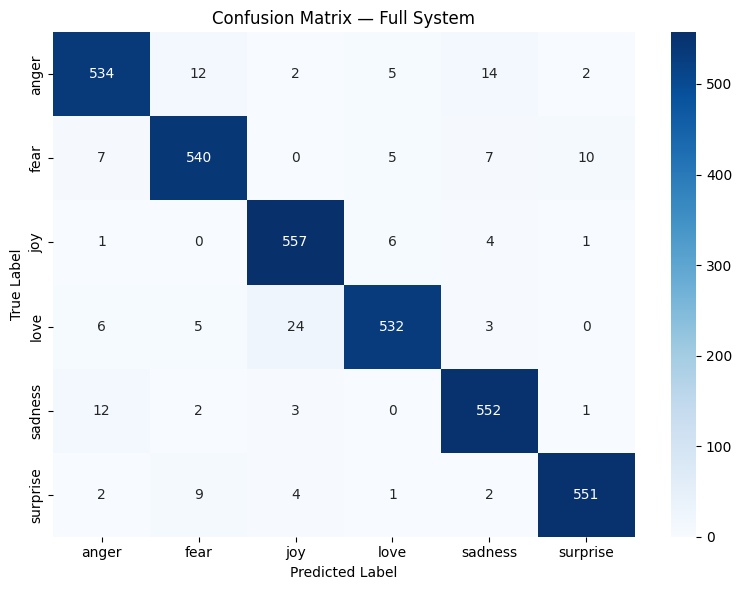

In [50]:
v_final = run_validation(model, val_loader, device, temp_model=temp_model)

print('Classification Report — Full System (with Temperature Scaling):')
print(classification_report(v_final['true'], v_final['preds'], target_names=le.classes_))

cm = confusion_matrix(v_final['true'], v_final['preds'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix — Full System')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.tight_layout(); plt.show()

## 20 — Per-Class Uncertainty Analysis

In [51]:
print('Per-class uncertainty analysis:')
print(f'{"Emotion":<12} {"Avg Confidence":>16} {"Avg Entropy":>13} {"Accuracy":>10}')
print('-' * 55)

for i, emotion in enumerate(le.classes_):
    mask = v_final['true'] == i
    if mask.sum() > 0:
        avg_conf = v_final['confidences'][mask].mean()
        avg_ent  = v_final['entropies'][mask].mean()
        acc      = (v_final['preds'][mask] == v_final['true'][mask]).mean()
        print(f'{emotion:<12} {avg_conf:>16.4f} {avg_ent:>13.4f} {acc:>10.4f}')

Per-class uncertainty analysis:
Emotion        Avg Confidence   Avg Entropy   Accuracy
-------------------------------------------------------
anger                  0.9667        0.1425     0.9385
fear                   0.9638        0.1449     0.9490
joy                    0.9764        0.1038     0.9789
love                   0.9743        0.1175     0.9333
sadness                0.9786        0.1087     0.9684
surprise               0.9629        0.1680     0.9684


## 21 — Uncertainty Distribution (Correct vs Incorrect)

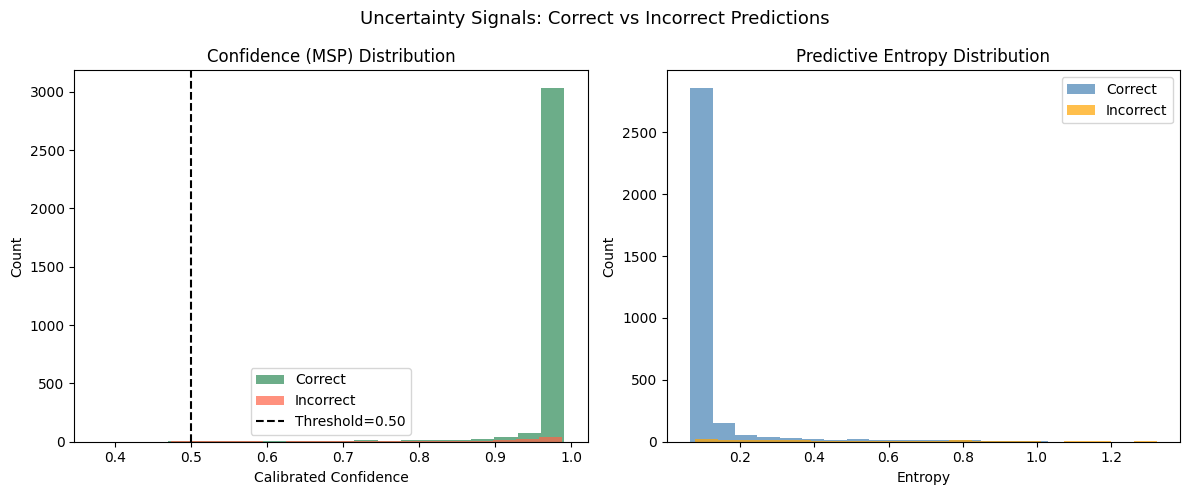

Confidence — Correct: 0.9770 | Incorrect: 0.8283
Entropy    — Correct: 0.1149 | Incorrect: 0.4786


In [52]:
correct   = (v_final['preds'] == v_final['true'])
incorrect = ~correct

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(v_final['confidences'][correct],   bins=20, alpha=0.7, color='seagreen', label='Correct')
axes[0].hist(v_final['confidences'][incorrect], bins=20, alpha=0.7, color='tomato',   label='Incorrect')
axes[0].axvline(CONFIDENCE_THRESHOLD, color='black', linestyle='--',
                label=f'Threshold={CONFIDENCE_THRESHOLD:.2f}')
axes[0].set_title('Confidence (MSP) Distribution')
axes[0].set_xlabel('Calibrated Confidence'); axes[0].set_ylabel('Count'); axes[0].legend()

axes[1].hist(v_final['entropies'][correct],   bins=20, alpha=0.7, color='steelblue', label='Correct')
axes[1].hist(v_final['entropies'][incorrect], bins=20, alpha=0.7, color='orange',    label='Incorrect')
axes[1].set_title('Predictive Entropy Distribution')
axes[1].set_xlabel('Entropy'); axes[1].set_ylabel('Count'); axes[1].legend()

plt.suptitle('Uncertainty Signals: Correct vs Incorrect Predictions', fontsize=13)
plt.tight_layout(); plt.show()

print(f'Confidence — Correct: {v_final["confidences"][correct].mean():.4f} '
      f'| Incorrect: {v_final["confidences"][incorrect].mean():.4f}')
print(f'Entropy    — Correct: {v_final["entropies"][correct].mean():.4f} '
      f'| Incorrect: {v_final["entropies"][incorrect].mean():.4f}')

## 22 — Save All Model Components

In [53]:
import os
os.makedirs(SAVE_DIR, exist_ok=True)

# 1. RoBERTa model + tokenizer (HuggingFace format — required by app.py)
model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

# 2. Temperature scalar
torch.save(temp_model.state_dict(), f'{SAVE_DIR}/temperature_model.pt')

# 3. Label encoder
joblib.dump(le, f'{SAVE_DIR}/label_encoder.pkl')

# 4. Config
config = {
    'base_model'           : MODEL_NAME,
    'loss'                 : 'WeightedCrossEntropyLoss',
    'class_weights'        : class_weights.tolist(),
    'optimizer'            : 'AdamW(lr=2e-5, weight_decay=0.01)',
    'scheduler'            : 'LinearWarmup(warmup_ratio=0.1)',
    'epochs'               : EPOCHS,
    'batch_size'           : BATCH_SIZE,
    'max_length'           : MAX_LEN,
    'confidence_threshold' : float(CONFIDENCE_THRESHOLD),
    'lexicon_weight'       : LEXICON_WEIGHT,
    'temperature'          : round(temp_model.temperature.item(), 6),
    'num_labels'           : num_labels,
    'labels'               : list(le.classes_)
}
with open(f'{SAVE_DIR}/inference_config.json', 'w') as f:   # fix: renamed from config.json
    json.dump(config, f, indent=2)

print(f'All components saved to: {SAVE_DIR}')
for item in ['model + tokenizer', 'best_checkpoint.pt',
             'temperature_model.pt', 'label_encoder.pkl', 'inference_config.json']:
    print(f'   ✅ {item}')

All components saved to: ./emotion_model_final
   ✅ model + tokenizer
   ✅ best_checkpoint.pt
   ✅ temperature_model.pt
   ✅ label_encoder.pkl
   ✅ config.json


## 24 — Download for Deployment
> Download `emotion_model_final.zip` and unzip into `reflectly-main/ml-service/`.
> The folder must contain: `config.json`, `pytorch_model.bin`, tokenizer files, `temperature_model.pt`, `label_encoder.pkl`.

In [54]:
import shutil
from google.colab import files

shutil.make_archive('emotion_model_final', 'zip', '.', 'emotion_model_final')
files.download('emotion_model_final.zip')
print('Download started — place the unzipped folder at: reflectly-main/ml-service/emotion_model_final/')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started — place the unzipped folder at: reflectly-main/ml-service/emotion_model_final/
